## Data preparation Crop Yield Prediction

Things to consider:  
    - OHE for season, crop type, soil type

In [71]:
# Import curated dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../data/processed/curated_crop_yield_dataset.csv", parse_dates=['Date'])
df.columns.to_list()

['Date',
 'Crop_Type',
 'Soil_Type',
 'Soil_pH',
 'Temperature',
 'Humidity',
 'Wind_Speed',
 'N',
 'P',
 'K',
 'Crop_Yield',
 'Soil_Quality',
 'Month',
 'NPK_sum',
 'NPK_balance_cv',
 'N_ratio',
 'P_ratio',
 'K_ratio',
 'Season']

In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR 
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

# --- Define target and features ---
target = 'Crop_Yield'
numeric_features = ['Temperature', 'Humidity', 'Wind_Speed', 'Soil_Quality', 'Soil_pH', 'N', 'P', 'K']
categorical_features = ['Crop_Type', 'Soil_Type', 'Season']

X = df[numeric_features + categorical_features]
y = df[target]

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [73]:
# --- Preprocessing ---
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

# --- Model pipeline ---
model = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', LinearRegression())
])

# --- Fit and evaluate ---
model.fit(X_train, y_train)
preds = model.predict(X_test)

r2 = r2_score(y_test, preds)
rmse = root_mean_squared_error(y_test, preds)

print(f"R²:   {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R²:   0.6495
RMSE: 15.2882


In [74]:
import xgboost as xgb

# Different models and performance comparison
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'XGB': xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
}

results = {}
for name, reg in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('regressor', reg)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    results[name] = {
        'R2': r2_score(y_test, preds),
        'RMSE': root_mean_squared_error(y_test, preds)
    }

import pandas as pd
print(pd.DataFrame(results).T.sort_values('R2', ascending=False))

                        R2       RMSE
XGB               0.975561   4.036905
RandomForest      0.974921   4.089403
KNN               0.928133   6.922645
GradientBoosting  0.923268   7.153113
SVR               0.833292  10.543506
LinearRegression  0.649489  15.288245
Ridge             0.649488  15.288271
Lasso             0.592810  16.478027


In [75]:
from sklearn.model_selection import cross_val_score

rf_pipe = Pipeline([('preprocess', preprocessor), 
                     ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))])
scores = cross_val_score(rf_pipe, X, y, cv=5, scoring='r2')
print(scores, scores.mean(), scores.std())

[0.97415245 0.97615182 0.97522618 0.97656386 0.97716183] 0.9758512280561528 0.0010575822362719556


In [76]:
xgb_pipe = Pipeline([('preprocess', preprocessor),
                     ('regressor', xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42))])
scores = cross_val_score(xgb_pipe, X, y, cv=5, scoring='r2')
print(scores, scores.mean(), scores.std())

[0.97495357 0.97620201 0.97571091 0.97694513 0.97742679] 0.9762476821014106 0.0008765485964509361


In [77]:
rf_pipe.fit(X_train, y_train)  # fit it for real this time

importances = rf_pipe.named_steps['regressor'].feature_importances_
feature_names = rf_pipe.named_steps['preprocess'].get_feature_names_out()

importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(importance_df.head(15))

num__Temperature            0.573477
num__Humidity               0.163327
num__Soil_Quality           0.089007
cat__Crop_Type_Sugarcane    0.040904
cat__Crop_Type_Rice         0.040168
cat__Crop_Type_Tomato       0.038874
num__N                      0.022739
num__P                      0.010462
cat__Crop_Type_Corn         0.007556
num__Wind_Speed             0.007383
cat__Crop_Type_Cotton       0.001240
num__K                      0.000930
cat__Season_Spring          0.000725
cat__Season_Winter          0.000693
num__Soil_pH                0.000644
dtype: float64


In [78]:
xgb_pipe.fit(X_train, y_train)

importances = xgb_pipe.named_steps['regressor'].feature_importances_
feature_names = xgb_pipe.named_steps['preprocess'].get_feature_names_out()

importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(importance_df.head(15))

cat__Crop_Type_Rice         0.173807
cat__Crop_Type_Sugarcane    0.171849
num__Humidity               0.159207
cat__Crop_Type_Tomato       0.153069
num__Temperature            0.140238
num__Soil_Quality           0.065493
cat__Crop_Type_Corn         0.061831
num__N                      0.044418
num__P                      0.010674
cat__Crop_Type_Cotton       0.005951
cat__Soil_Type_Sandy        0.003363
num__K                      0.002760
num__Soil_pH                0.001629
cat__Crop_Type_Wheat        0.001028
num__Wind_Speed             0.000785
dtype: float32


In [79]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'regressor__max_depth': [3, 4, 5, 6, 7, 9],
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__n_estimators': [100, 200, 300, 500],
    'regressor__subsample': [0.7, 0.8, 0.9, 1.0],
    'regressor__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_dist,
    n_iter=30,          # only 30 random combos instead of all 384
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)
print("Best parameters:", random_search.best_params_)
print("Best CV R²:", random_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'regressor__subsample': 0.7, 'regressor__n_estimators': 500, 'regressor__max_depth': 6, 'regressor__learning_rate': 0.05, 'regressor__colsample_bytree': 0.9}
Best CV R²: 0.9773965459645639


In [80]:
best_model = random_search.best_estimator_
preds = best_model.predict(X_test)

print("Test R²:", r2_score(y_test, preds))
print("Test RMSE:", root_mean_squared_error(y_test, preds))

Test R²: 0.977388778556035
Test RMSE: 3.8830135509299812


In [81]:
import shap

# Extract the fitted regressor and preprocessor from best pipeline
best_model = random_search.best_estimator_
regressor = best_model.named_steps['regressor']
preprocessor_fitted = best_model.named_steps['preprocess']

# Transform the test data (and get feature names)
X_test_transformed = preprocessor_fitted.transform(X_test)
feature_names = preprocessor_fitted.get_feature_names_out()

# If sparse matrix, convert to dense
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# SHAP explainer for tree models
explainer = shap.TreeExplainer(regressor)
shap_values = explainer.shap_values(X_test_transformed)

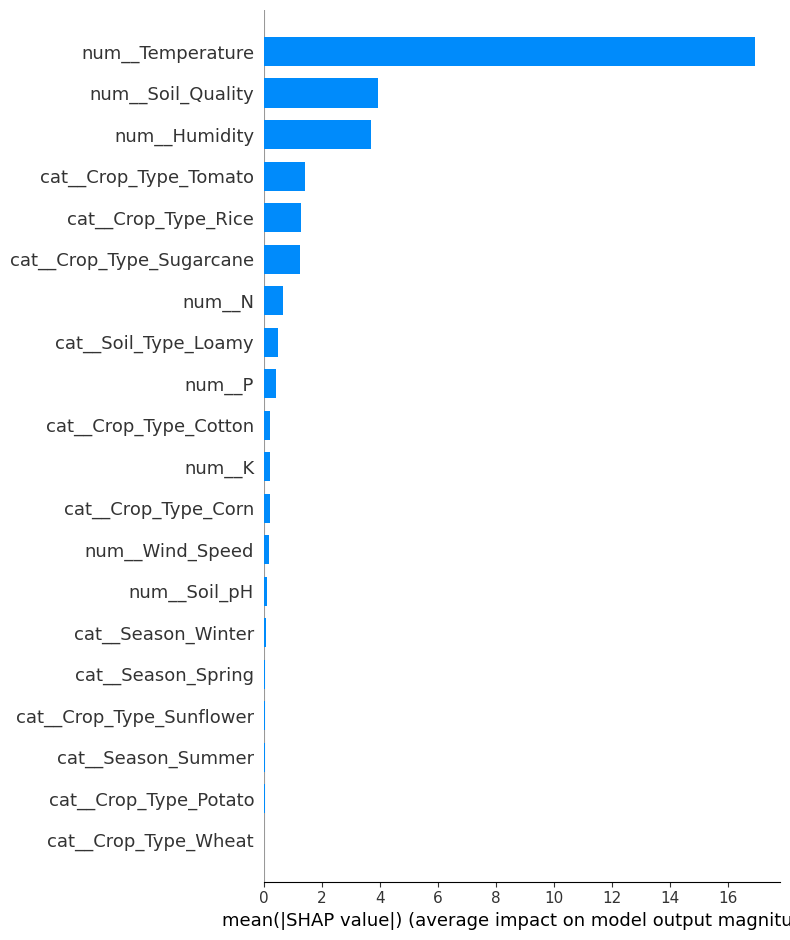

In [82]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar")

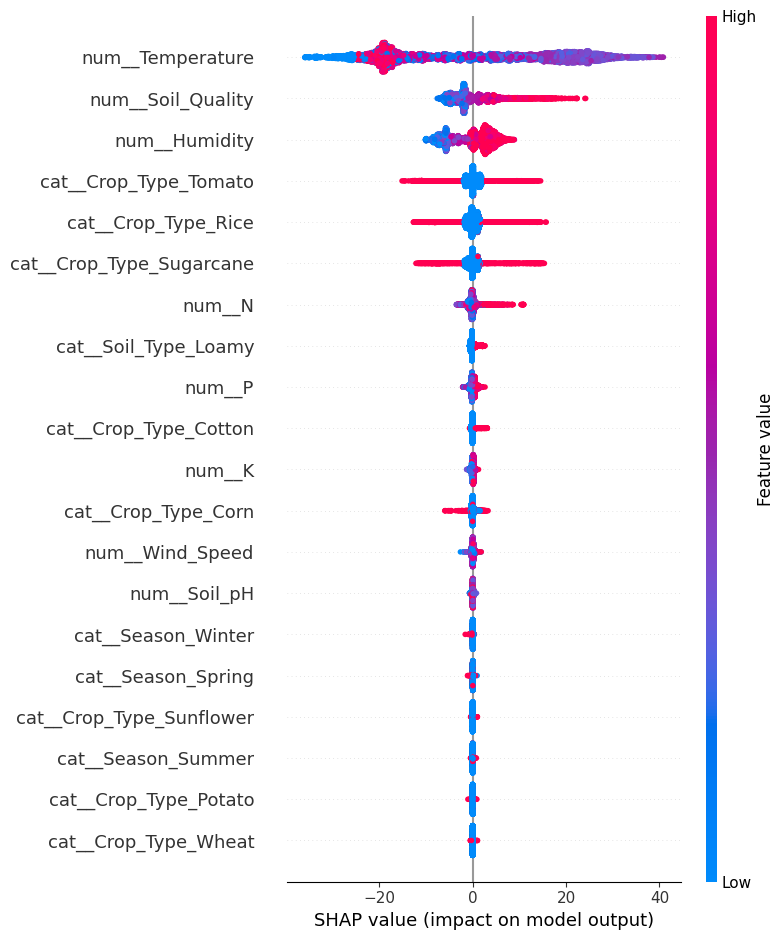

In [83]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)